In [1]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, \
RocCurveDisplay, roc_auc_score, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import log_loss
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor, BaggingClassifier, BaggingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import ridge_regression, ElasticNet
from sklearn.linear_model import Ridge


In [2]:
df = pd.read_csv('../Cases/Concrete_Strength/Concrete_Data.csv')
df

,Cement,Blast,Fly,Water,Superplasticizer,Coarse,Fine,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [3]:
x,y = df.drop('Strength', axis = 1),df['Strength']

Scaling

In [8]:
scaler = StandardScaler()

Ohe not required here

In [ ]:
# ohe = OneHotEncoder(drop='first', sparse_output=False)
# col_trnf = ColumnTransformer((['OHE', ohe, make_column_selector(dtype_include=object)]),
#                              remainder='passthrough',
#                              verbose_feature_names_out=False).set_output(transform = 'pandas')

# ohe = OneHotEncoder(drop = 'first', sparse_output = False)
# col_trnf = ColumnTransformer([('OHE', ohe,make_column_selector(dtype_include=object) )],
#                              remainder='passthrough',
#                              verbose_feature_names_out=False)

# col_trnf = col_trnf.set_output(transform = 'pandas')

# x = col_trnf.fit_transform(x)

In [4]:
x_train, x_test , y_train, y_test = train_test_split(x,y, random_state=25, test_size=0.3)

Random Forest without Scaling

In [ ]:
features = [2,3,4,5]
n_est = [25, 50, 100, 150, 200]
scores = []
for f in tqdm(features):
    for n in n_est:
        rf = RandomForestRegressor(random_state = 25, max_features=f, n_estimators=n)
        rf.fit(x_train, y_train)
        y_pred = rf.predict(x_test)
        scores.append([f,n,mean_absolute_error(y_test, y_pred)])

df_scores = pd.DataFrame(data = scores, columns = ['No. of Features', 'No of Estimators', 'mean_absolute_error'])
df_scores.sort_values('mean_absolute_error', ascending=False)

,No. of Features,No of Estimators,mean_absolute_error
0,2,25,4.105068
5,3,25,4.079459
1,2,50,4.052459
2,2,100,4.030801
3,2,150,3.994757
4,2,200,3.972731
6,3,50,3.951527
7,3,100,3.876212
8,3,150,3.866549
15,5,25,3.860518


Random Forest with scaling

In [9]:
# pipe = Pipeline()

features = [2,3,4,5]
n_est = [25, 50, 100, 150, 200]
scores = []
for f in tqdm(features):
    for n in n_est:
        
        rf = RandomForestRegressor(random_state = 25, max_features=f, n_estimators=n)
        pipe = Pipeline([('Scaling', scaler), ('RandomForest', rf)])
        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)
        scores.append([f,n,mean_absolute_error(y_test, y_pred)])

df_scores = pd.DataFrame(data = scores, columns = ['No. of Features', 'No of Estimators', 'mean_absolute_error'])
df_scores.sort_values('mean_absolute_error', ascending=False)

100%|██████████| 4/4 [00:05<00:00,  1.40s/it]


,No. of Features,No of Estimators,mean_absolute_error
0,2,25,4.111520
5,3,25,4.081987
1,2,50,4.063326
2,2,100,4.036934
3,2,150,4.001506
4,2,200,3.979155
6,3,50,3.951402
7,3,100,3.880969
8,3,150,3.868882
15,5,25,3.866464


Feature Importance

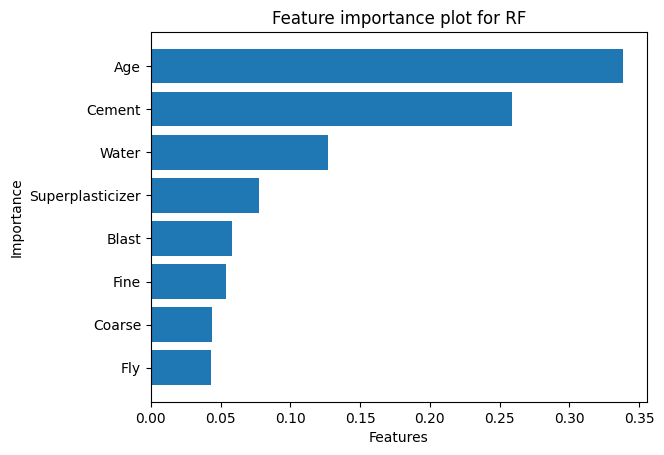

In [6]:
best_model = RandomForestRegressor(random_state=25, max_features=4, n_estimators=200)
best_model.fit(x_train, y_train)
df_imp = pd.DataFrame({'Features':list(x.columns), 'Importance': best_model.feature_importances_})
df_imp.sort_values('Importance', inplace=True)
plt.barh(df_imp['Features'], df_imp['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature importance plot for RF')
plt.show()